#### LangGraph에서 도구(tool) 활용 방법

- 도구(tool)를 활용한 에이전트 개발 방법을 알아봅니다
- workflow를 직접 선언하지 않고, 사용가능한 도구들을 전달하면, 에이전트가 적합한 도구를 판단해서 사용합니다
    - 이번 회차에서는 `ToolNode`를 통해 도구를 활용하는 방법을 알아봅니다

In [2]:
from dotenv import load_dotenv
import os
# .env 파일을 불러와서 환경 변수로 설정
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
print(OPENAI_API_KEY[:5])

UPSTAGE_API_KEY = os.getenv("UPSTAGE_API_KEY")
print(UPSTAGE_API_KEY[:5])

sk-pr
up_gq


In [3]:
from langchain_upstage import ChatUpstage
llm = ChatUpstage(
        model="solar-pro",
        base_url="https://api.upstage.ai/v1",
        temperature=0.5
    )
print(llm.model_name)

# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(
#     model='gpt-4o-mini', 
#     temperature=0,
# )
# print(llm.model_name)

c:\ai_langchain\mylangchin-uv-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


solar-pro


In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

- LangGraph는 `ToolNode`를 통해 도구를 활용합니다
- `ToolNode`의 `invoke()`결과는 도구의 `invoke()` 결과와 유사합니다
    - 도구는 도구의 실행 결과를 리턴하고, `ToolNode`는 도구의 실행 결과를 포함한 `ToolMessage`를 리턴합니다

In [5]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]
llm_with_tools = llm.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

print(type(llm_with_tools))
print(tool_node)

<class 'langchain_core.runnables.base.RunnableBinding'>
tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'add': StructuredTool(name='add', description='숫자 a와 b를 더합니다.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002CE71666C00>), 'multiply': StructuredTool(name='multiply', description='숫자 a와 b를 곱합니다.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002CE71AC7C40>)}, _injected_args={'add': _InjectedArgs(state={}, store=None, runtime=None), 'multiply': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x000002CE71CF45E0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)


In [6]:
result = multiply.invoke({'a': 3, 'b': 5})

print(type(result))
result

<class 'int'>


15

In [7]:
ai_message = llm_with_tools.invoke('3 더하기 5는 얼마인가요?')
ai_message

AIMessage(content="[The 'add' function is ESSENTIAL to calculate the sum of 3 and 5, which directly answers the question. No other functions are necessary.]", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 580, 'total_tokens': 632, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 576}}, 'model_provider': 'openai', 'model_name': 'solar-pro2-251215', 'system_fingerprint': None, 'id': '102a4d94-cc9f-48b3-91b6-7a74b32fc5ff', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be2d2-ba9d-7a33-9913-cf6c845d9aa0-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'chatcmpl-tool-b12d7deb3b04463bacfb9bc54582bff2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 580, 'output_tokens': 52, 'total_tokens': 632, 'input_token_detai

In [8]:
ai_message.tool_calls

[{'name': 'add',
  'args': {'a': 3, 'b': 5},
  'id': 'chatcmpl-tool-b12d7deb3b04463bacfb9bc54582bff2',
  'type': 'tool_call'}]

- `ToolNode`를 `invoke()`하려면 `tool_calls` 속성을 포함한 `AIMessage`를 전달해야 합니다

In [10]:
# tool_msg = tool_node.invoke({'messages': [ai_message]})

# print(type(tool_msg))
# tool_msg

- 간단한 에이전트를 만들기 위해 LangGraph에서 제공하는 [`StateGraph`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)를 사용합니다

In [11]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [12]:
def agent(state: MessagesState) -> MessagesState:
    """
    에이전트 함수는 주어진 상태에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (MessagesState): 메시지 상태를 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    # 상태에서 메시지를 추출합니다.
    messages = state['messages']
    
    # LLM과 도구를 사용하여 메시지를 처리하고 응답을 생성합니다. (RunnableBinding)
    response = llm_with_tools.invoke(messages)
    
    # 응답 메시지를 새로운 상태로 반환합니다.
    return {'messages': [response]}

In [13]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: MessagesState) -> Literal['tools', END]:
    """
    주어진 메시지 상태를 기반으로 에이전트가 계속 진행할지 여부를 결정합니다.

    Args:
        state (MessagesState): `state`를 포함하는 객체.

    Returns:
        Literal['tools', END]: 도구를 사용해야 하면 `tools`를 리턴하고, 
        답변할 준비가 되었다면 END를 반환해서 프로세스를 종료합니다.
    """
    # 상태에서 메시지를 추출합니다.
    messages = state['messages']
    print(type(messages))
    print(messages)
    
    # 마지막 AI 메시지를 가져옵니다.
    last_ai_message = messages[-1]
    
    # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
    if last_ai_message.tool_calls:
        # 도구 호출이 있으면 'tools'를 반환합니다.
        return 'tools'
    
    # 도구 호출이 없으면 END를 반환하여 프로세스를 종료합니다.
    return END

- `node`를 추가하고 `edge`로 연결합니다

In [14]:
graph_builder.add_node('agent', agent)
#tool_node = ToolNode(tool_list)
graph_builder.add_node('tools', tool_node)

graph_builder.nodes

{'agent': StateNodeSpec(runnable=agent(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class 'langgraph.graph.message.MessagesState'>, retry_policy=None, cache_policy=None, ends=(), defer=False),
 'tools': StateNodeSpec(runnable=tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'add': StructuredTool(name='add', description='숫자 a와 b를 더합니다.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002CE71666C00>), 'multiply': StructuredTool(name='multiply', description='숫자 a와 b를 곱합니다.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002CE71AC7C40>)}, _injected_args={'add': _InjectedArgs(state={}, store=None, runtime=None), 'multiply': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x00

In [15]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)
graph_builder.add_edge('tools', 'agent')

graph_builder.edges

{('__start__', 'agent'), ('tools', 'agent')}

<class 'langgraph.graph.state.CompiledStateGraph'>


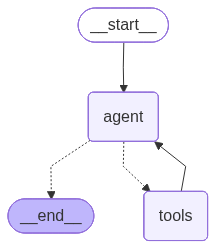

In [16]:
graph= graph_builder.compile()
print(type(graph))

graph

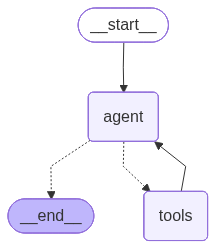

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
mermaid_code = graph.get_graph().draw_mermaid()
print("Mermaid Code:")
print(mermaid_code)

Mermaid Code:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



* https://mermaid.live/ 에서  mermain_code 로 직접 확인한다.


- `graph.stream()`을 활용하면 에이전트가 답변을 생성하는 과정을 모니터링 할 수 있습니다

In [20]:
from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages': [HumanMessage('3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요?')]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요?
<class 'list'>
[HumanMessage(content='3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요?', additional_kwargs={}, response_metadata={}, id='c977751e-3df4-4c3e-b181-714946ccb74f'), AIMessage(content="[Brief explanation: \n1. 'add' 함수는 3과 5를 더하는 필수적인 계산을 수행합니다. \n2. 'multiply' 함수는 덧셈 결과에 8을 곱하는 후속 계산을 위해 필요합니다. \n두 함수 호출 모두 문제 해결에 직접적으로 요구되며, 더 간단한 방법으로는 답변할 수 없습니다.] \n\n*참고: 실제 구현에서는 첫 번째 함수(add)의 결과를 두 번째 함수(multiply)의 입력으로 전달하기 위해 중간 변수(result_of_add)가 필요합니다. 이는 문제 해결을 위한 최소한의 필수 단계입니다. 최종 답은 64입니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 588, 'total_tokens': 726, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 560}}, 'model_provider': 'openai', 'model_name': 'solar-pr

#### LangGraph 내장 ReAct 에이전트 사용
* create_react_agent()의 작동 방식
    * create_react_agent() 함수 내부에서 이미 StateGraph와 필요한 노드(사고, 도구 실행, 응답 생성 등)를 자동으로 구성합니다.

* LangChain 1.2.6에서는 langgraph.prebuilt.create_react_agent 대신 langchain.agents.create_agent를 사용하며, system_prompt를 추가해야 ReAct 에이전트가 제대로 동작합니다.

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain.agents import tool

from langchain_core.messages import HumanMessage
from langchain_upstage import ChatUpstage

llm = ChatUpstage(
        model="solar-pro",
        base_url="https://api.upstage.ai/v1",
        temperature=0.5
    )
print(llm)

# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(
#     model='gpt-3.5-turbo-0125', 
#     temperature=0,
# )
# print(llm.model_name)

@tool
def add2(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

# 한 줄로 에이전트 생성 - 내부에서 StateGraph를 자동 구성

agent = create_react_agent(model=llm, tools=[add2])
print(type(agent))

# 바로 사용 가능
result = agent.invoke({"messages": [HumanMessage(content="3+5는?")]})

print(result)

gpt-3.5-turbo-0125
<class 'langgraph.graph.state.CompiledStateGraph'>
{'messages': [HumanMessage(content='3+5는?', additional_kwargs={}, response_metadata={}, id='28ddd74f-cb59-4833-81ef-e7f49baabb2f'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_SXILXoQJEHJ0J4gFooRL3TEr', 'function': {'arguments': '{"a":3,"b":5}', 'name': 'add2'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 58, 'total_tokens': 76, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CJxbSrhDOBr2yIhRy1EQlpRUG4I9r', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--5fc29783-deaf-4446-a159-69bddd71c290-0', tool_calls=[{'name': 'add2', 'args': {'a': 3, 'b': 5}, '

#### create_agent()
* LangChain 1.2.6에서는 langgraph.prebuilt.create_react_agent 대신 langchain.agents.create_agent를 사용하며, system_prompt를 추가해야 ReAct 에이전트가 제대로 동작합니다.

In [25]:
from langchain.agents import create_agent
from langchain_core.tools import tool  # v1에서 langchain_core.tools.tool 사용
from langchain_core.messages import HumanMessage

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     model='gpt-3.5-turbo-0125', 
#     temperature=0,
# )
# print(llm.model_name)

from langchain_upstage import ChatUpstage

llm = ChatUpstage(
        model="solar-pro",
        base_url="https://api.upstage.ai/v1",
        temperature=0.5
    )
print(llm.model_name)

@tool
def add2(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply2(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

# ReAct 에이전트 생성 - system_prompt 추가 (create_react_agent 대체)
agent = create_agent(
    model=llm, 
    tools=[add2, multiply2],
    system_prompt="You are a helpful assistant with access to tools."  # ReAct 동작을 위한 기본 지시
)
print(type(agent))

# 바로 사용 가능
result = agent.invoke({"messages": [HumanMessage(content="3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요??")]})
print(result)


solar-pro
<class 'langgraph.graph.state.CompiledStateGraph'>
{'messages': [HumanMessage(content='3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요??', additional_kwargs={}, response_metadata={}, id='5632987b-4ad6-412b-9575-513638db0377'), AIMessage(content="[Brief explanation: 'add2'는 3과 5를 더하는 필수 단계이며, 그 결과에 8을 곱하는 'multiply2'는 최종 답을 얻기 위해 반드시 필요합니다. 두 함수 호출 모두 문제 해결에 직접적으로 요구됩니다.]  \n\n*참고: 실제 실행 시에는 `result_of_add2`를 첫 번째 함수(`add2`)의 반환값으로 대체해야 합니다. 예를 들어, `add2(3,5)=8`이므로 두 번째 호출은 `multiply2(a=8, b=8)`이 됩니다. 최종 결과는 64입니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 601, 'total_tokens': 751, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 592}}, 'model_provider': 'openai', 'model_name': 'solar-pro2-251215', 'system_fingerprint': None, 'id': '7e9a8dc9-3dd6-436b-bd67-39069726f62e', 

In [27]:
from pprint import pprint

pprint(result['messages'])

[HumanMessage(content='3에다 5를 더한 결과에 다시 8을 곱하면 얼마인가요??', additional_kwargs={}, response_metadata={}, id='5632987b-4ad6-412b-9575-513638db0377'),
 AIMessage(content="[Brief explanation: 'add2'는 3과 5를 더하는 필수 단계이며, 그 결과에 8을 곱하는 'multiply2'는 최종 답을 얻기 위해 반드시 필요합니다. 두 함수 호출 모두 문제 해결에 직접적으로 요구됩니다.]  \n\n*참고: 실제 실행 시에는 `result_of_add2`를 첫 번째 함수(`add2`)의 반환값으로 대체해야 합니다. 예를 들어, `add2(3,5)=8`이므로 두 번째 호출은 `multiply2(a=8, b=8)`이 됩니다. 최종 결과는 64입니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 601, 'total_tokens': 751, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 592}}, 'model_provider': 'openai', 'model_name': 'solar-pro2-251215', 'system_fingerprint': None, 'id': '7e9a8dc9-3dd6-436b-bd67-39069726f62e', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be2dd-87

In [28]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool  # v1 표준 import
from langchain_core.messages import HumanMessage

# 더 복잡한 도구들 정의 (변경 없음)
@tool
def calculate_compound_interest(principal: float, rate: float, years: int) -> str:
    """원금, 이자율, 기간을 받아 복리 이자를 계산합니다."""
    amount = principal * (1 + rate/100) ** years
    interest = amount - principal
    return f"{years}년 후 원리금: {amount:,.0f}원, 이자: {interest:,.0f}원"

@tool
def calculate_tax(income: float) -> str:
    """연소득을 받아 간이 세액을 계산합니다."""
    if income <= 12000000:
        tax = income * 0.06
    elif income <= 46000000:
        tax = 720000 + (income - 12000000) * 0.15
    elif income <= 88000000:
        tax = 5820000 + (income - 46000000) * 0.24
    else:
        tax = 15900000 + (income - 88000000) * 0.35
    
    return f"예상 세액: {tax:,.0f}원, 세후 소득: {income - tax:,.0f}원"

@tool
def get_weekday(date_str: str) -> str:
    """YYYY-MM-DD 형식의 날짜를 받아 요일을 반환합니다."""
    from datetime import datetime
    date_obj = datetime.strptime(date_str, "%Y-%m-%d")
    weekdays = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]
    return f"{date_str}은 {weekdays[date_obj.weekday()]}입니다."

# LLM 초기화 (변경 없음)
llm = ChatOpenAI(model="gpt-3.5-turbo")
print(llm.model_name)

# 도구 리스트 (변경 없음)
tools_list = [calculate_compound_interest, calculate_tax, get_weekday]

# ReAct 에이전트 생성 - v1 API 사용
agent = create_agent(
    model=llm, 
    tools=tools_list,
    system_prompt="당신은 도움이 되는 어시스턴트입니다. 사용자의 질문을 이해하고 적절한 도구를 사용하여 정확한 답변을 제공하세요."
)
print(type(agent))

gpt-3.5-turbo
<class 'langgraph.graph.state.CompiledStateGraph'>


In [30]:

# 복합적인 질문 테스트
complex_questions = [
    "1억원을 연 5% 복리로 10년 동안 예금하면 얼마가 될까?",
    "연소득 5천만원일 때 내야 할 세금은 얼마야?",
    "2026년 1월 22일은 무슨 요일이야?",
    "연소득 8천만원일 때 세금을 계산하고, 남은 돈을 연 4% 복리로 5년간 예금하면 얼마가 돼?"
]

for question in complex_questions:
    print(f"\n질문: {question}")
    print("-" * 50)
    
    result = agent.invoke({"messages": [HumanMessage(content=question)]})
    response = result["messages"][-1].content
    
    print(f"답변: {response}")
    print("=" * 80)


질문: 1억원을 연 5% 복리로 10년 동안 예금하면 얼마가 될까?
--------------------------------------------------
답변: 1억원을 연 5% 복리로 10년 동안 예금하면 10년 후에는 약 1억 6천 2백 8십 9만 4천 6백 3원이 되고, 2022년 9월 13일은 수요일입니다.

질문: 연소득 5천만원일 때 내야 할 세금은 얼마야?
--------------------------------------------------
답변: 연소득 5천만원에 대한 간이 세액은 6,780,000원이며, 세후 소득은 43,220,000원입니다.

질문: 2026년 1월 22일은 무슨 요일이야?
--------------------------------------------------
답변: 2026년 1월 22일은 목요일입니다.

질문: 연소득 8천만원일 때 세금을 계산하고, 남은 돈을 연 4% 복리로 5년간 예금하면 얼마가 돼?
--------------------------------------------------
답변: 연소득 8천만원일 때 세금을 계산하면 예상 세액은 13,980,000원이며, 이에 따라 세후 소득은 66,020,000원이 됩니다. 이후 세후 소득을 연 4% 복리로 5년간 예금하면 5년 후 원리금은 80,323,425원이 되며, 이 중 이자는 14,303,425원입니다.


In [31]:
complex_questions = [
    "1억원을 연 5% 복리로 10년 동안 예금하면 얼마가 될까?",
    "연소득 5천만원일 때 내야 할 세금은 얼마야?",
    "2026년 1월 22일은 무슨 요일이야?",
    "연소득 8천만원일 때 세금을 계산하고, 남은 돈을 연 4% 복리로 5년간 예금하면 얼마가 돼?"
]

for question in complex_questions:
    for chunk in agent.stream({'messages': [HumanMessage(content=question)]}, stream_mode='values'):
        chunk['messages'][-1].pretty_print()

================================ Human Message =================================

1억원을 연 5% 복리로 10년 동안 예금하면 얼마가 될까?
================================== Ai Message ==================================
Tool Calls:
  calculate_compound_interest (call_cgDHuXHWAGJ28kDb1PnLeaGg)
 Call ID: call_cgDHuXHWAGJ28kDb1PnLeaGg
  Args:
    principal: 100000000
    rate: 5
    years: 10
================================= Tool Message =================================
Name: calculate_compound_interest

10년 후 원리금: 162,889,463원, 이자: 62,889,463원
================================== Ai Message ==================================

1억원을 연 5% 복리로 10년 동안 예금하면 10년 후에는 원금과 이자를 합한 총 금액이 1억 628만 8946천 463원이 됩니다. 원금은 1억원이며, 이자로 인해 62,889,463원이 더해지게 됩니다.
================================ Human Message =================================

연소득 5천만원일 때 내야 할 세금은 얼마야?
================================== Ai Message ==================================
Tool Calls:
  calculate_tax (call_eHAgE2U7KHwJUgAocwQCgSp4)
 Call ID: call_eHAgE2U7KH